# Design of a Constant Air Volume (CAV) heating system with an economizer 

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/mateotournoud/ce4ac_2026.git/main?urlpath=%2Fdoc%2Ftree%2FHeating-Economizer-Project.ipynb)

Authors:
- Fiant, Cristian
- Tournoud, Mateo
- Nekouei, Ali

### Introduction

This project models a recycled air heating system with an economizer under the constant air volume (CAV) assumption. The goal is to verify wether the system satisfies the thermal and humidity demands of an office space. The model is based on a mass and energy balances for each component. The following characteristics are provided:
- Characteristics of the office: dimensions of the room, width of the wall, infiltration flow rate.
- Characteristics of the people: number of people, clothing, activities.
- Desired ambient conditions inside the room: temperature, humidity.

The outdoor chara


### The model

Outdoor air (state 0) is mixed with recirculated return air in the mixing unit (MX), conditioned by the heating coil (HC) and vapor humidifier (VH), and supplied to the thermal zone (TZ). The building (BL) imposes sensible and latent (Qs, Ql) loads. Feedback controllers (kw and kth) regulate the humidification and heating to maintain the indoor setpoints (θsp, wsp).

First, the user can define the weather conditions for his own purposes by modifying the boundary conditions. The second part of this Jupyter Notebook includes a section where real weather data in .epw format can be imported and used.

![reva_ghiaus.drawio (1).png](<attachment:reva_ghiaus.drawio (1).png>)

## Boundary conditions

In [1]:
# Libraries
import numpy as np

# Outdoor temperature (CHANGE HERE):
θOd = 9            # °C, outdoor temperarture

# Outdoor humidity (CHANGE HERE):
φO = 0.9              # Humidity ratio of the outdoor air
phi_o = 0.9         # outdoor relative humidity (CHECK NORMS)

nr_people = 5       # number of people in the room
season = "winter"   # season, either "summer", "autumn", "winter" or "spring"

# Constants
R = 8314    # J/(kmol·K), gas constant
M_da, M_v = 28.9645, 18     # kg/kmol, molar mass dry air; water vapor
c_da, c_v  = 1e3, 1.96e3    # J/(kg·K), specific heat
l_v = 2495.0e3              # J/kg, specific latent heat

## Building desing and BC calculation

In [2]:
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import matplotlib.pyplot as plt
import va_hum

### Building description

For this project, we are considering one floor of a building which has been designed for placing offices. In each floor, there are two offices and a shared space which allows access to both of them. Each volume can be considered as a separate thermal zone, although we will work in the begining with one single thermal zone.

The walls, the doors and the windows are boundary conditions. As we consider an intermediate floor of this building, the floor and the roof are considered to be adiabatic.


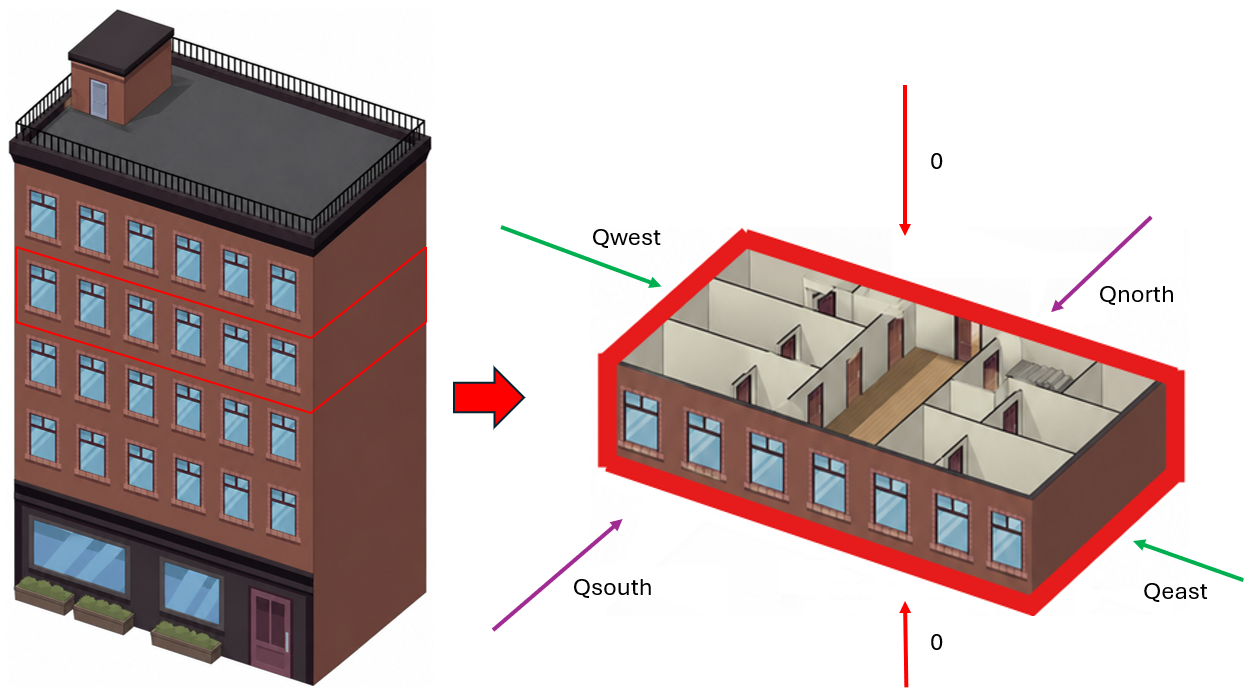


All the coefficients adopted for this project are obtained from _PsychroAn_tuto/T02_load_winter.ipynb_ (Ghiaus, 2022). 


**Characteristics of the building components**

In this project, the floor and the ceiling are considered adiabatic. No coefficients are adopted for the floor nor the ceiling.


|Layer           |width|conductivity|density|specific heat|
|----------------|-----|-----------:|------:|------------:|
|                |$w$/m|$\lambda$/(W·m⁻¹·K⁻¹)| $\rho$/(kg·m⁻³)|$c$/(J·kg⁻¹·K⁻¹)|
|$\textbf{External wall}$| |        |       |    |
|Exterior plaster| 0.01| 0.8        | 1200  |1000|
|Insulation      | 0.12| 0.035      | 80    |840|
|Plaster         | 0.03| 1.00       | 1200  |1000|
|Honeycomb brick | 0.30| 0.22       | 800   |1000|
|Internal plaster| 0.01| 1.0        | 1200  |1000|
|$\textbf{Internal wall}$| |        |       |    |
|Internal plaster| 0.01| 0.35       | 1200  |1000|
|Honeycomb brick | 0.24| 0.33       | 1000  |1000|
|Internal plaster| 0.01| 0.35       | 1200  |1000|
|$\textbf{Exterior door}$| |        |       |    |
|Wood            | 0.04| 0.131      | 600   |1000|



In [3]:
# External wall
# plaster, insulation, plaster, brick, plaster
we = np.array([0.01, 0.120,  0.03, 0.30, 0.01])       # m, width
λe = np.array([0.80, 0.035,  1.00, 0.22, 1.00])       # W/(m·K), conductivity
ρe = np.array([1200,    80,  1200, 800,  1200])       # kg/m³, density
ce = np.array([1000,   840,  1000, 1000, 1000])       # J/(kg·K), specific heat

# Internal wall
# plaster, brick, plaster
wi = np.array([0.01, 0.24, 0.01])       # m, width
λi = np.array([0.35, 0.33, 0.35])       # W/(m·K), conductivity
ρi = np.array([1200, 1000, 1200])       # kg/m³, density
ci = np.array([1000, 1000, 1000])       # J/(kg·K), specific heat

# Exterior door
wd = 0.040   # m, width
λd = 0.131   # W/(m·K), conductivity
ρd = 600     # kg/m³, density
cd = 1000    # J/(kg·K), specific heat

**Thermal bridge: External wall to external wall**

For this specific project, as the floor and the ceiling are considered adiabatic, the only bridge which has to be studied is the external-wall-to-external-wall bridge.

In [4]:
psi = 0.091 # W/mK, thermal bridge, external wall to external wall

**Window**

In [5]:
U_window = 1.2 # W/m2K, overall heat transfer coefficient of the window

**Convection coefficients**

In [6]:
hi = 8.0 # W/m2K, indoor convective coefficient
ho = 25.0 # W/m2K, outdoor convective coefficient

**Temperatures and humidity** ([Norme NF EN 12831](https://www.thermexcel.com/french/ressourc/calcul_deperdition_calculs_deperditions.htm))


outdoor humidity (for Lyon) [Norme NF EN 12831](https://www.thermexcel.com/french/energie/Calcul_deperditions_thermiques_NF_EN_12831.htm)


**Occupants** ([EnergiePlus](https://energieplus-lesite.be/theories/bilan-thermique44/charges-thermiques-internes-pour-les-bureaux/#Lapport_des_occupants))

The following table specifies the boundary conditions for people doing office work in summer, autumn, winter and spring.

|Season|Indoor temperature|Sensible heat|Latent heat|Total heat|Vapor mass flow per person|
|----------------|-----|-----------|------|------------|------------|
|Summer| 26°C | 63 W | 69 W | 132 W | 99 g/h |
|Autumn| 24°C | 71 W | 60 W | 131 W | 86 g/h |
|Winter| 26°C | 83 W | 49 W | 132 W | 71 g/h |
|Spring| 24°C | 71 W | 60 W | 131 W | 86 g/h |


For this case, we assume the winter conditions as our Air Handling Unit will only perform heating.



In [7]:
q_sensible = 83 # W
q_latent = 49 # W
vapor_massflow = 71 # g/h

print("Number of people in the room: ", nr_people)
print("Sensible heat load: ", q_sensible, " W")
print("Latent heat load: ", q_latent, " W")
print("Total heat load: ", q_sensible + q_latent, " W")
print("Vapor mass flow rate: ", vapor_massflow, " g/h")

Number of people in the room:  5
Sensible heat load:  83  W
Latent heat load:  49  W
Total heat load:  132  W
Vapor mass flow rate:  71  g/h


**Lighting and electrical equipments** ([EnergiePlus](https://energieplus-lesite.be/theories/bilan-thermique44/charges-thermiques-internes-pour-les-bureaux/#Lapport_des_equipements))

In [8]:
computer = 50 # W
screen = 150 # W
printer = 200 # W

electrical_equipment_load = nr_people * (computer + screen) + printer  # W
print("Electrical equipment load: ", electrical_equipment_load, " W")

Electrical equipment load:  1200  W


**Air leackage for the whole ground floor**

- $n_{50}=2.49$ air changes per hour at 50 Pa
- $ACH=n_{50}/n=1.62/12$ air changes per hour at 4 Pa ([A. Meier, 1986](https://www.aivc.org/sites/default/files/airbase_3097.pdf), [ASHRAE 2017 p.16.23-26](https://archive.org/details/ashraehandbook2017hvacfundamentalssi/mode/1up), [Yongming Ji et al. 2022](https://doi.org/10.1016/j.enbenv.2022.02.010)).

In [9]:
n50 = 2.49 # air changes per hour at 50 Pa, from blower door test
n50_4pa = 1.62 / 12 # air changes per hour at 4 Pa

**Supply air temperature**

- $t_S = t_I+15~\mathrm{°C}$ for heating

In [10]:
t_supply = 33 # °C, supply air temperature for heating
print("Supply air temperature for heating: ", t_supply, "°C")

Supply air temperature for heating:  33 °C


**Notes:**

1) The [surfaces](http://construction.senova.fr/conseils-techniques/shob-et-shon-cest-fini-tout-sur-la-nouvelle-surface-de-plancher/) considered in thermal calculations are the indoor ones. 

2) The [air leackeage mesured at 50 Pa needs to be corrected](https://unmethours.com/question/26477/how-to-set-air-infiltration-under-50-pa-pressure/) for lower pressure (about 4 Pa), which is the normal pressure when the wind is not very strong.

### Calculate

**Overall heat transfer coefficient**

The overall conductivity of a plane wall is:
$$U = \frac{1}{\frac{1}{h_i} + \sum \frac{w}{\lambda} + \frac{1}{h_o}}$$
where:
- $h_i$ - indoor convection coefficient, W/m²·K
- $h_o$ - outdoor convection coefficient, W/m²·K
- $\lambda$ - thermal conductivity, W/m·K
- $w$ - width, m.

This equation will be implemented to calculate the heat transfer coefficient of the external and internal walls and doors. In the case of the internal walls and doors, the convection coefficient outside and inside is the same ($h = h_i$)

In [11]:
Ue = 1/(1/hi + np.sum(we/λe) + 1/ho)   # W/(m²·K), external walls
print(f"Ue = {Ue:5.3f} W/(m²·K), external wall")

Ui = 1/(2/hi + np.sum(wi/λi))          # W/(m²·K), internal walls
print(f"Ui =  {Ui:5.3f} W/(m²·K), internal wall")

Udo = 1/(1/hi + wd/λd + 1/ho)          # W/(m²·K), external door
print(f"Udo = {Udo:5.3f} W/(m²·K), external door")

Udi = 1/(2/hi + wd/λd)                 # W/(m²·K), internal door
print(f"Udi = {Udi:5.3f} W/(m²·K), internal door")

Ue = 0.200 W/(m²·K), external wall
Ui =  0.967 W/(m²·K), internal wall
Udo = 2.126 W/(m²·K), external door
Udi = 1.801 W/(m²·K), internal door


### Surfaces

Using the [definition of surfaces](http://construction.senova.fr/conseils-techniques/shob-et-shon-cest-fini-tout-sur-la-nouvelle-surface-de-plancher/), calculate the surfaces of: 
- window, $S_w$ in m²; 
- exterior door, $S_d$  in m²;
- exterior walls surface, $S_e$ in m²;

to be used for heat transfert through the building envelope. As we are first calculating a single thermal zone, no internal doors or walls will be calculated yet.

In [12]:
surface_window = 1.2 * 1.5 # m², surface of the window
surface_door = 1.4 * 2.2 # m², surface of the exterior door

floor_height = 3.2 # m, height of the floor
north_wall = 11.0 * floor_height - 6* surface_window # m², surface of the north wall
south_wall = north_wall # m², surface of the south wall
east_wall = (4.8 + 2.4) * floor_height # m², surface of the east wall
west_wall = east_wall - surface_door # m², surface of the west wall

### Building characteristics

In a simplified approach, the heat transmission coefficient $UA$ is the sum of conductances [Recknagel (2007), p. 888]:

$$UA = \sum_{i}f_i U_i S_i+ \sum_{i} \psi_i L_i$$

> Table 1. Correction for heat loss in the simplified method (Recknagel, 2007, Table 2.4.1-5, p. 889)

| Heat loss ... |$f_i$ |
|---------------|------|
|... direct to outside | 1.00 if thermal bridges are considered     |
|                      | 1.40 if thermal bridges are not considered |
|... toward an unheated room | 0.80 if thermal bridges are considered |
|                            | 1.12 if thermal bridges are not considered|
|... towards the ground or an adjoining part of the building | 0.30 if thermal bridges are considered |
|                             | 0.42 if thermal bridges are not considered|
|... through the roof or a low floor over a crawl space | 0.90 if thermal bridges are considered |
|                              | 1.26 if thermal bridges are not considered |
|... toward an adjoining building | 0.50 if thermal bridges are considered |
|                              | 0.70 if thermal bridges are not considered |

More detailed information on the calculation of overall heat trasmitance is given in French regulations ([RT2000, Règles Th-U](https://sti2d.ecolelamache.org/Regles_TH-U_1_5.pdf)).

In [13]:
# Overall heat coeffcient
Uw = 1.2                               # W/(m²·K), U-window
ψWF = 0.107                            # W/(m·K), ψ wall-floor
ψWC = 0.084                            # W/(m·K), ψ wall-ceiling
ψWW = 0.091                            # W/(m·K), ψ wall-wall
f = 0.8                                # correction factor for unheated room
UA = (Ue*north_wall +                  # northern wall
      Ue*south_wall +                  # southern wall
      Ue*east_wall +                   # eastern wall
      Ue*west_wall +                   # western wall
      Uw*12*surface_window +           # windows
      Udo*surface_door +               # exterior door
      ψWF*4*(10.05 - 2*0.35)/2 +       # hor. therm bridge wall-floor
      ψWC*4*(10.05 - 2*0.35)/2 +       # hor. therm bridge wall-ceiling
      ψWW*4*2.495)                     # vert. therm bridge wall-wall
print(f'UA = U·S +  ψ·L = {UA:5.1f} W/K, overall heat transfer coefficient')

UA = U·S +  ψ·L =  55.3 W/K, overall heat transfer coefficient


The air flow rate is estimated differently for natural and for mechanical ventilation. For natural ventiation, the total air fow rate is the sum of the minimal air flow rate and the infiltration rate; for mechanical ventilation, the supply air flow rate is added.

> Table 2. Minimum air changes per hour (ACH) (Recknagel, 2007, Table 2.4.1-4 p. 884 and Table 3.5.1-1 p. 1358)

| Type of room                 | ACH/h⁻¹ |
|------------------------------|:---------:|
| Living space, kitchen > 20 m³| 0.5 |
| Office, kitchen < 20 m³      | 1.0 |
| WC or bathroom with window   | 1.5 |
| Meeting room, classroom      | 2 .. 6|
| Toillets - houses            | 4 .. 5|
| Toillets - offices           | 5 .. 8|
| Library                      | 3 .. 5|
| Bars and coffe shops         | 5 .. 10|
| Auditoriums                  | 8 .. 10|
| Cafeteria                    | 6 .. 8|
| Shops                        | 4 .. 6|
| Cinemas and theaters         | 4 .. 6|
| Swimings pools               | 3 .. 4|

The air flow rate of the mechanical ventilation system is $\dot V_m = 120\, \mathrm{m^3/h}$ ([Strachan P., Heusler I., 2015](https://pure.strath.ac.uk/ws/portalfiles/portal/43362532/Empirical_Modelling_Specification_200514.pdf), §3.8 Ventilation).

Air ventilation rate by mechanical ventilation is:
$$ACH = \frac{\dot V_m}{V_z}$$
where:
- $\dot V_m$ - air flow rate by ventilation, m³/h;
- $V_z$ - volume of the zone, m³.

The infiltration flow rate (ACH) depends on the volume of the space and the air leackage $n_{50}$:

$$ ACH = \frac{n_{50}}{n} $$

where $n$ is a correction factor in order to  consider the air changes per hour (ACH) at a normal pressure difference (at 4 Pa) ([A. Meier, 1986](https://www.aivc.org/sites/default/files/airbase_3097.pdf), [ASHRAE, 2017 p.16.23-26](https://archive.org/details/ashraehandbook2017hvacfundamentalssi/mode/1up), [Yongming Ji et al., 2022](https://doi.org/10.1016/j.enbenv.2022.02.010)).

The value $n_{50}=2.49$ air changes per hour at 50 Pa was measured experimentally by using a [blower door](https://en.m.wikipedia.org/wiki/Blower_door) ([Strachan P., Heusler I., 2015](https://pure.strath.ac.uk/ws/portalfiles/portal/43362532/Empirical_Modelling_Specification_200514.pdf), §3.10 Air leakge).

In [14]:
Vz = floor_height * (7 + 4) * (2.4 + 4.8)  # m³, zone volume
print(f'Vz = {Vz:.1f} m³, zone volume')

vo = 0.75                                  # m³/kg, specific volume
Vm = 120                                   # m³/h, mechanical ventilation
mv = Vm / vo / 3600
print(f'mv =  {mv:.6f} kg/s, ventilation air flow rate')

ACH = Vm / Vz
print(f"Ventilation rate ACH = {ACH:.2}/h")

# Infiltration mass flow rate
n50 = 2.49              # h⁻¹, infiltration rate at 50 Pa
n = 12                  # correction for exposed, 1.5 stories
ACH = n50 / n           # infiltration rate corrected for normal wind pressure
minf = ACH * Vz / vo / 3600     # kg/s, outdoor dry air mass flow rate
print(f'mi =  {minf:.4f} kg/s, air infiltration')

Vz = 253.4 m³, zone volume
mv =  0.044444 kg/s, ventilation air flow rate
Ventilation rate ACH = 0.47/h
mi =  0.0195 kg/s, air infiltration


The auxiliary sensible heat is from occupants and electrical devices:

$$\dot Q_{sa} = p_e S_f + n_p q_p$$

where:
- $p_e$ is the electrical power per unit of surface ([EnergiePlus](https://energieplus-lesite.be/theories/bilan-thermique44/charges-thermiques-internes-pour-les-bureaux/#Lapport_des_equipements)), W/m²;
- $S_f$ - floor area, m²
- $n_p$ - number of persons;
- $q_p$ - sensible heat of a person ([EnergiePlus](https://energieplus-lesite.be/theories/bilan-thermique44/charges-thermiques-internes-pour-les-bureaux/#Lapport_des_occupants)), W.

The auxiliary latent heat is given mainly by the occupants:

$$ \dot Q_{la} = n_p \dot m_{vp} $$

where:
- $n_p$ is the number of persons;
- $\dot m_{vp}$ - vapor mass flow per person ([EnergiePlus](https://energieplus-lesite.be/theories/bilan-thermique44/charges-thermiques-internes-pour-les-bureaux/#Lapport_des_occupants)), kg/s.

In [15]:
# Auxilairy sensible heat
qsp = 83 # W/person, sensible heat per person
Qsa = electrical_equipment_load + nr_people * qsp # W, sensible auxiliary heat
print(f'Qsa =  {Qsa:5.1f} W, sensible aux. heat')

# Auxiliary latent heat
wi, wo = 8.7e-3, 1.6e-3  # kg/kgₐ, humidity ratio
mvp = 71e-3 / 3600       # kg/s, vapor mass flow per person
Qla = nr_people * mvp * l_v
print(f'Qla = {Qla:5.1f} W, latent aux. heat')

Qsad = Qsa/1000    # W
UAd = UA/1000 
Qlad = Qla/1000     # kJ/K, overall heat conductance

Qsa =  1615.0 W, sensible aux. heat
Qla = 246.0 W, latent aux. heat


## Heater

In the following section, the working of the model will be described:

### Constant air volume (CAV)

- supply air mass flow rate: constant - determined for design conditions
- supply temperature varies

The `RecAirCAV` function from module `va_hum.py` was modified to the unique purpose of this design; it is stored in `ce4ac_rec_air_cav.py`

In [16]:
from ce4ac_rec_air_cav import RecAirCAV

# Boundary conditions of this section:
θO_design = -1
θSd = 33            # °C supply air temperature
θId = 23            # °C, indoor temperature
φIsp = 0.5          # Humidity ratio of the setpoint
phi_i = 0         # indoor relative humidity

m, v, Q = RecAirCAV(c=c_da, l=l_v, α=0.1, θS=θSd, θIsp=θId, φIsp=φIsp, θOd=θOd, θO_design=θO_design, φO=φO, Qsa=Qsad, Qla=Qlad, mi=minf, UA=UAd) 


Winter Recirculated_air CAV
m =  0.047 kg/s constant (from design conditions)
Design conditions θS =  33.0 °C,mi = 0.0 kg/s, θO = -1.0 °C, θI = 23.0 °C
wO = 0.00641


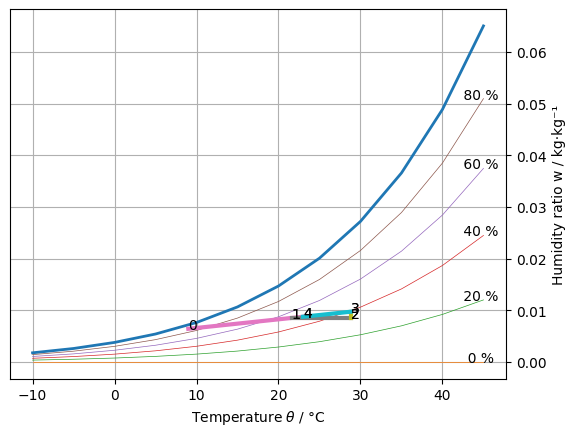


  θ [°C] w [g/kg]
0   9.00     6.41
1  21.60     8.51
2  28.82     8.51
3  28.82     9.72
4  23.00     8.75

   QsHC  QlVH  QsTZ  QlTZ
0  0.34  0.14 -0.27 -0.11 kW
3.826875
Total power: 0.478 kW
Total electrical power: 228.799 W


In [17]:
from ce4ac_rec_air_cav import RecAirCAV

m, v, Q = RecAirCAV(c=c_da, l=l_v, α=0.1, θS=θSd, θIsp=θId, φIsp=φIsp, θOd=θOd, θO_design=θO_design, φO=φO, Qsa=Qsad, Qla=Qlad, mi=minf, UA=UAd, verbose=True) 


Q_heater = Q['QsHC']
Q_total = Q['QsHC'] + Q['QlVH']

T_hot = θSd + 273.15
T_cold = θOd + 273.15

COP_carnot = T_hot / (T_hot - T_cold)
eta_hp = 0.3 
COP_real = eta_hp * COP_carnot
print(COP_real)

Pel_heater = Q['QsHC'] / COP_real + Q['QlVH']

print(f"Total power: {Q_total/1000:.3f} kW")

print(f"Total electrical power: {Pel_heater:.3f} W")


## Economizer

Applying the following energy balance equation and assuming Qs=0, the outlet temperature θo can be calculated for different ambient temperatures θTZ between 22°C and 24°C,corresponding to the free-cooling operating condition of the economizer.

$$
\dot{Q}_s = (UA + \dot{m}_i c)\,(\theta_o - \theta_{TZ}) + \dot{Q}_{s,a}
$$

Then we assume that:

$$
0= (UA + \dot{m}_i c)\,(\theta_o - \theta_{TZ}) + \dot{Q}_{s,a}
$$

Under free-cooling conditions, the heat source term is neglected, which simplifies the equation and allows the estimation of the outlet air temperature as a function of the surrounding temperature and the thermal exchange parameters of the system.

In [18]:
# inputs: the heat capacity of air (1 kJ/kg*K)
c = 1 #kJ/kg*K
θtz1 = 22 #°C
θtz2 = 24 #°C

# mass flow calculation (comes from the building desing)
ma = minf + mv #kg/sec

# denominator to maje the division easier later on
den = UAd + ma*c #kW/K


# outlet temperature calculation for different ambient temperatures θTZ (22°C and 24°C)
θ01 = θtz1 - Qsad / den #°C
θ02 = θtz2 - Qsad / den #°C

# print the oultlet temperatures for ambient temperatures θTZ (22°C and 24°C)
print(f"t01 = {θ01}")
print(f"t02 = {θ02}")

t01 = 8.450715429933735
t02 = 10.450715429933735


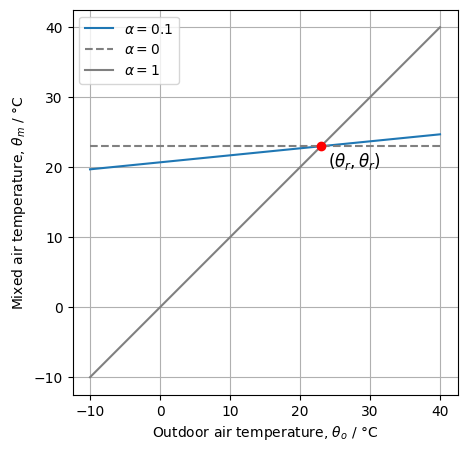

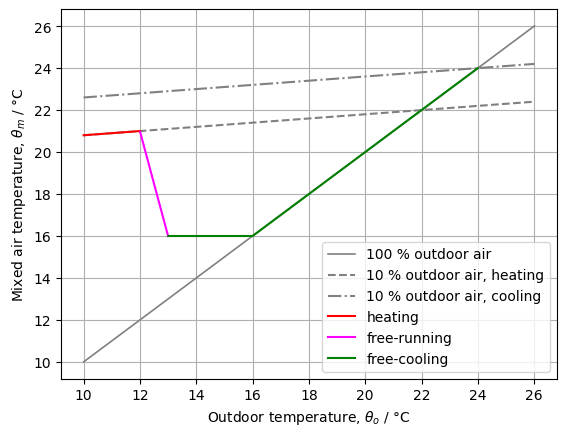

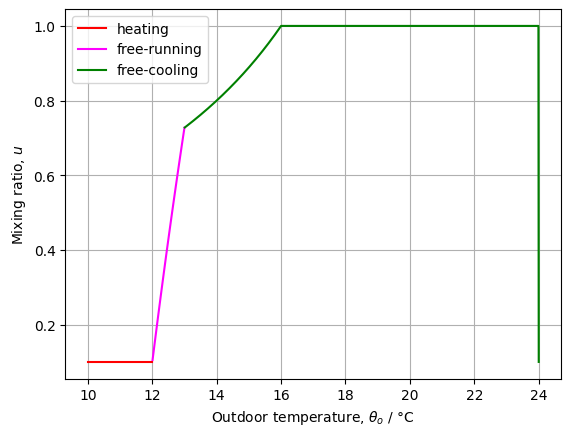

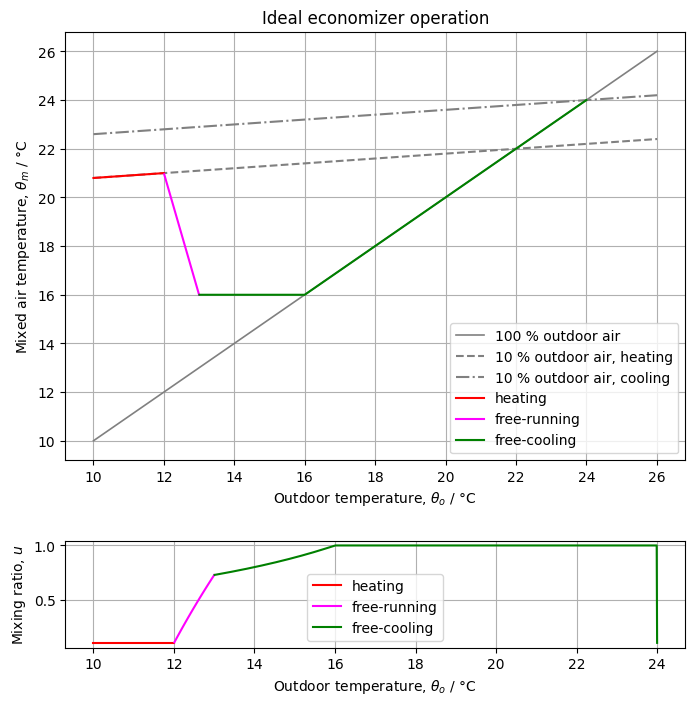

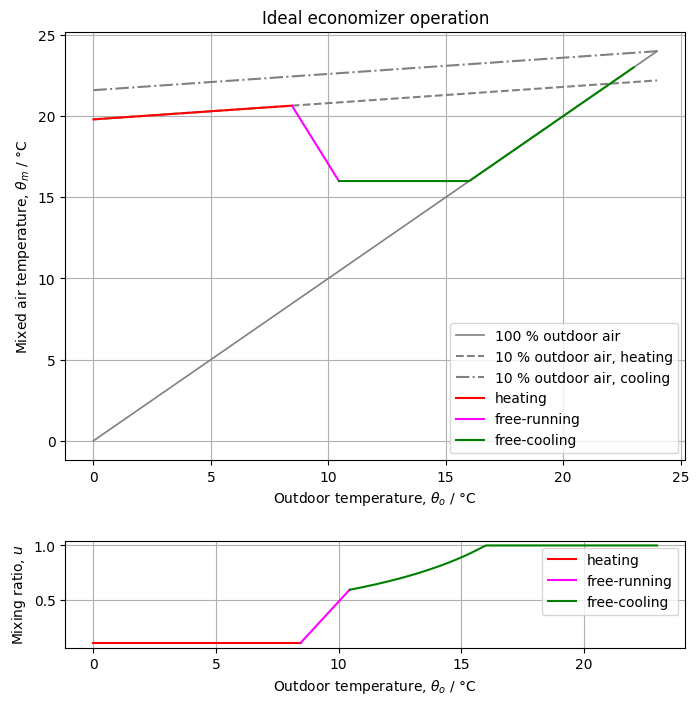

In [19]:
import economizer
θo = [0, 24, 0.01]     # °C, Outdoor temperarure from min to max with step dθo
θB = [θ01 , θ02]           # °C, Base temperature for heating θBh and cooling θBc
θM = 16              # °C, Mixed air temperature setpoint in free-cooling
θL = 23                # °C, Outdoor dry‑bulb limit setpoint for free-cooling
θr = [22, 24]           # °C,, Return air temperature for heating and cooling
α = 0.1                 # α ∈ [0, 1], Ratio of outdoor air in the mixed air

df_θm = economizer.ideal_mix_temp(θo, θB, θM, θL, θr, α)
df_u = economizer.mix_ratio(df_θm)
economizer.plot_mix_temp_ratio(df_θm, df_u)

## Heating with Economizer: mixing ratio and Power consumption calculation 

This section runs the simulator for the outdoor temperature set at the top of the notebook.

Based on the results from the Economizer section, the operating mode is determined — either `free-running`, `free-cooling`, or `heating` — and the following quantities are computed:
- Electric power consumed
- Mixing ratio

For `free-running` and `free-cooling`, the electric power consists of fan consumption only. For `heating`, it includes both the heat pump and the fan.

In [20]:
from single_point_analysis import SinglePointAnalysis
spa = SinglePointAnalysis(θ01=θ01, θ02=θ02, θSd=θSd, θId=θId, φIsp=φIsp, φO=φO, c_da=c_da, l_v=l_v, Qsa=Qsad, Qla=Qlad, minf=minf, UA=UAd, ma=ma, df_u=df_u, θB=θB)
result = spa.run(θout=θOd)

Mode: free-running
  Electric power (fan): 55.9441 W
  Mixing ratio:         0.2343


## Economizer algorithm

### Simulate the csv file (output: Mixing ratio and Energy consumption)

This simulation uses weather data from Dübendorf, Zurich, Switzerland, covering the period 2011–2025. Date selection is constrained to this range via the `start_date` and `end_date` parameters. Single-day or multi-day analyses are recommended.

To simulate a different location, replace the `.epw` file in the `Weather_Data` folder. Ensure only one `.epw` file is present in that folder at a time.

                        time  θout         state  mix_ratio  ma_kg_s  Energy_W
0  2000-03-20 00:00:00+01:00  1.00       heating       0.10     0.06    547.28
1  2000-03-20 01:00:00+01:00  0.20       heating       0.10     0.06    571.25
2  2000-03-20 02:00:00+01:00  1.00       heating       0.10     0.06    547.28
3  2000-03-20 03:00:00+01:00  0.00       heating       0.10     0.06    577.20
4  2000-03-20 04:00:00+01:00 -1.00       heating       0.10     0.06    606.66
5  2000-03-20 05:00:00+01:00 -1.00       heating       0.10     0.06    606.66
6  2000-03-20 06:00:00+01:00 -1.00       heating       0.10     0.06    606.66
7  2000-03-20 07:00:00+01:00  0.00       heating       0.10     0.06    577.20
8  2000-03-20 08:00:00+01:00  2.00       heating       0.10     0.06    516.86
9  2000-03-20 09:00:00+01:00  1.30       heating       0.10     0.06    538.21
10 2000-03-20 10:00:00+01:00  3.00       heating       0.10     0.06    485.88
11 2000-03-20 11:00:00+01:00  4.50       heating    

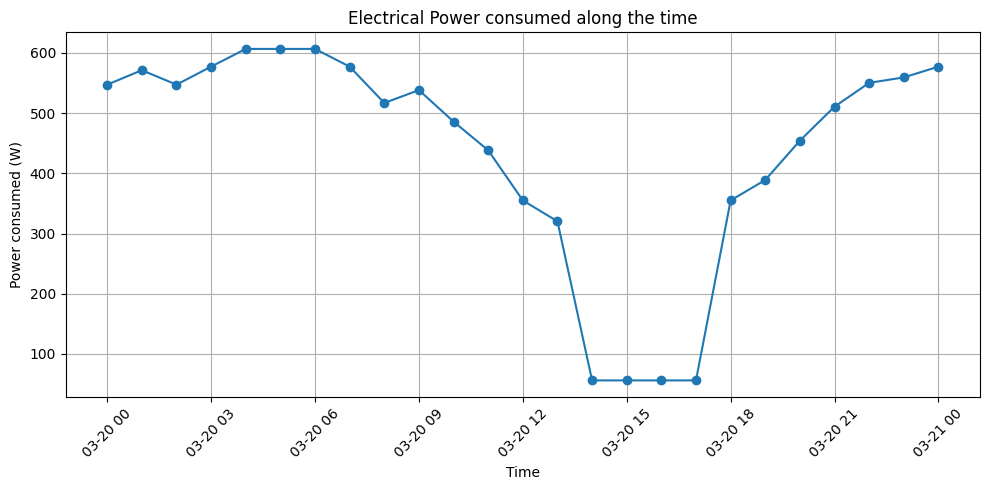

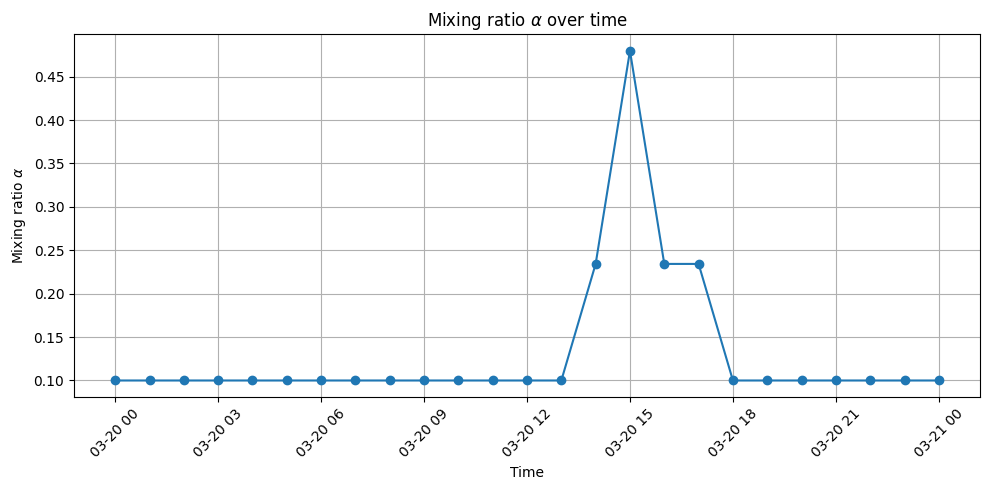

In [21]:
from economizer_algo import process_epw, plot_energy, plot_alpha_vs_time

start_date='2025-03-20'
end_date='2025-03-21'

df_results = process_epw(start_date=start_date, end_date=end_date, df_u=df_u, θ01=θ01, θ02=θ02, θB=θB, θL=θL, ma_const=ma, c_da=c_da, l_v=l_v, θSd=θSd, θId=θId, φIsp=φIsp, φO=φO, Qsad=Qsad, Qlad=Qlad, minf=minf, UAd=UAd, eta_hp=0.3)

print(df_results)
plot_energy(df_results)
plot_alpha_vs_time(df_results)

## Conclusions





## References